<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [1]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [6]:
customers = pd.read_csv('Wholesale customers data.csv')

#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [ ]:
missing_data = data.isnull().sum()

descriptive_stats = data.describe()

correlations = data.corr()

skewness = data.skew()

missing_data, descriptive_stats, correlations, skewness

<Figure size 800x400 with 0 Axes>

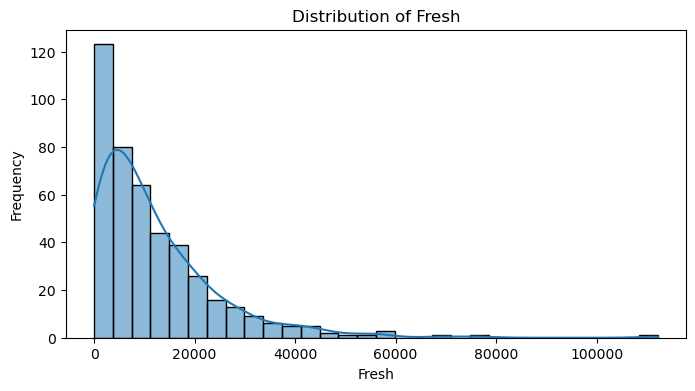

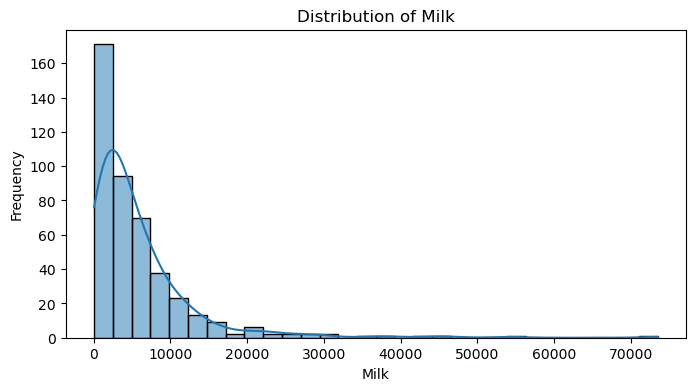

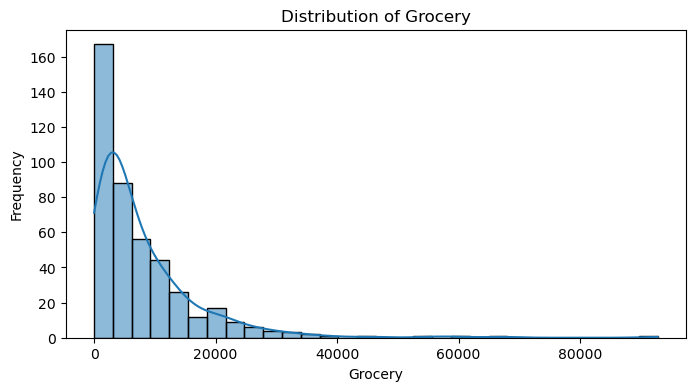

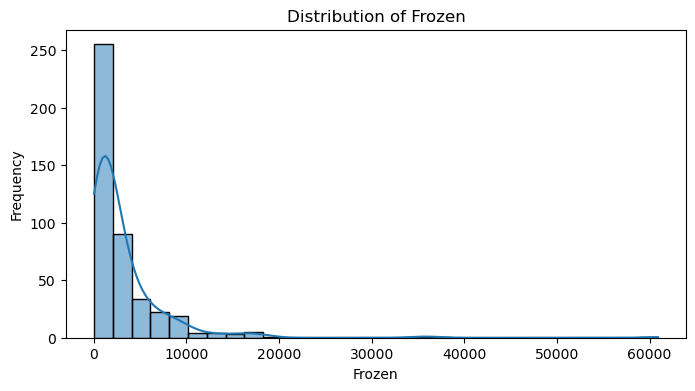

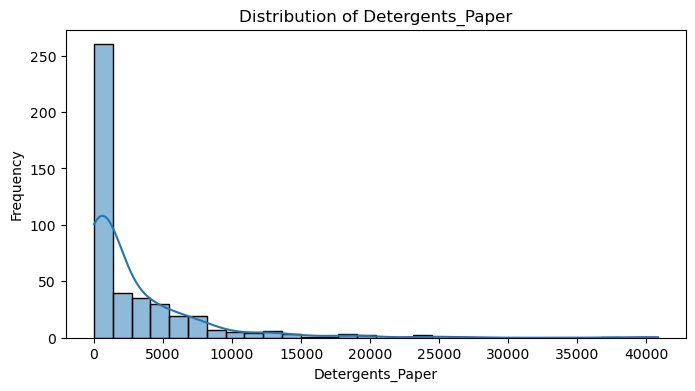

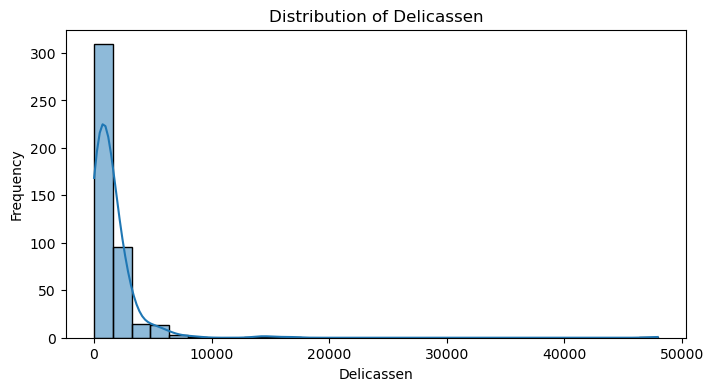

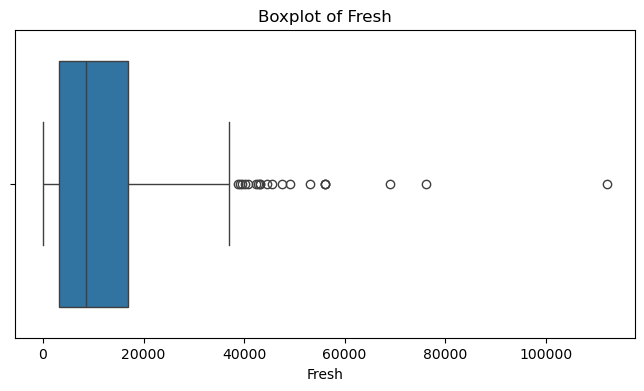

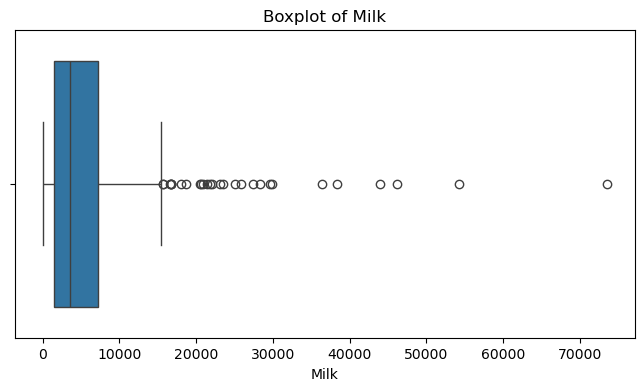

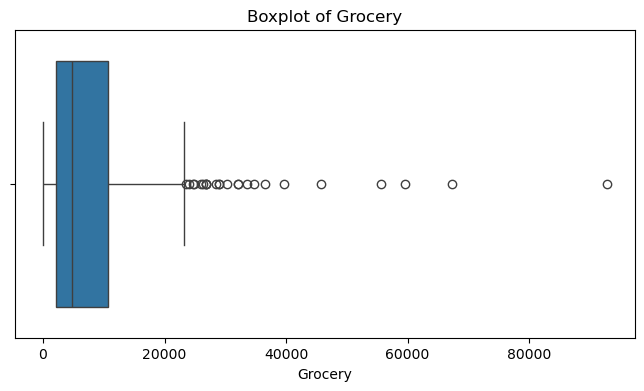

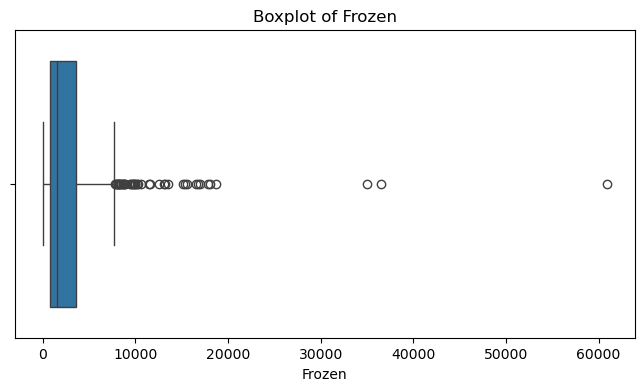

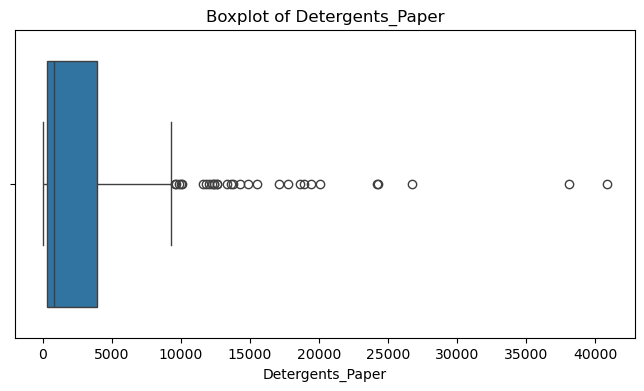

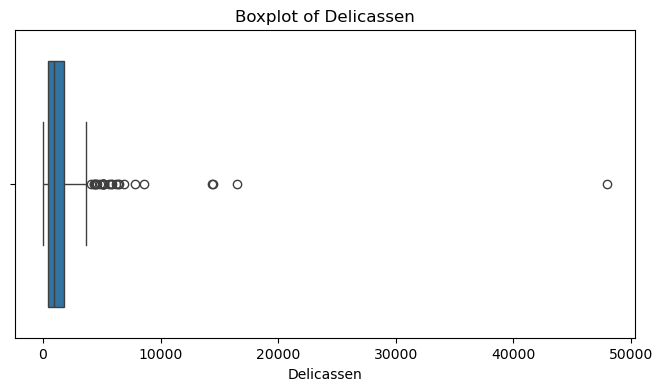

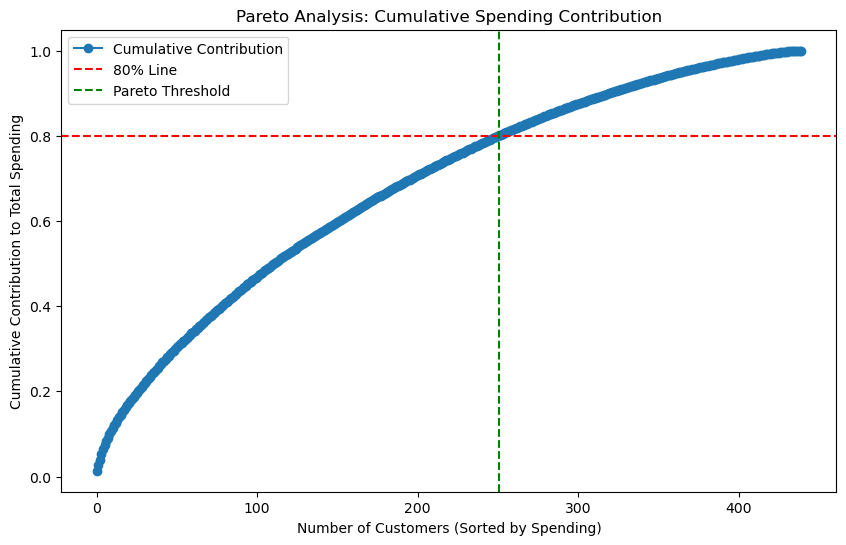

In [12]:
spending_columns = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

for col in spending_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(customers[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

for col in spending_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=customers[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

total_spending = customers[spending_columns].sum(axis=1)
pareto_data = total_spending.sort_values(ascending=False).reset_index(drop=True)
cumulative_contribution = pareto_data.cumsum() / pareto_data.sum()

plt.figure(figsize=(10, 6))
plt.plot(cumulative_contribution, marker='o', label='Cumulative Contribution')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Line')
plt.axvline(x=len(cumulative_contribution[cumulative_contribution <= 0.8]), color='g', linestyle='--', label='Pareto Threshold')
plt.title('Pareto Analysis: Cumulative Spending Contribution')
plt.xlabel('Number of Customers (Sorted by Spending)')
plt.ylabel('Cumulative Contribution to Total Spending')
plt.legend()
plt.show()

**Your observations here**

All spending columns exhibit heavy right-skewed distributions, indicating that most customers have low spending, while a few have very high spending.

Significant outliers are visible in all spending categories, especially in Fresh, Milk, Frozen, and Delicassen.

The Pareto analysis shows that approximately 20% of customers contribute to around 80% of the total spending. In this case, it aligns with the Pareto analysis. 


# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [18]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

customers_no_outliers = remove_outliers(customers, spending_columns)

original_size = customers.shape[0]
new_size = customers_no_outliers.shape[0]

original_size, new_size

(440, 318)

**Your comment here**

-  The outliers were removed. 

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [29]:
# Your import here:

from sklearn.preprocessing import StandardScaler


# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the data (excluding Channel and Region)
spending_customers = customers_no_outliers[spending_columns]
scaled_customers = scaler.fit_transform(spending_customers)

# Assign the scaled data to a new variable
customers_scale = pd.DataFrame(scaled_customers, columns=spending_columns)

# Display the first few rows of the scaled data
customers_scale.head()


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.360420,1.740710,0.432714,-0.984801,0.378277,0.451178
1,-0.325039,1.788015,0.867526,-0.023386,0.659241,1.009718
2,0.433216,-0.857996,-0.290889,2.859618,-0.605321,1.025020
3,-0.037274,1.311586,-0.094823,-0.704078,-0.020699,0.595276
4,0.294097,-0.242723,0.305758,-0.819597,0.589794,-0.560060


# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

In [49]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(customers_scale)

customers_no_outliers['labels'] = kmeans.labels_

customers_no_outliers.head()

C:\Users\torre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels
0,2,3,12669,9656,7561,214,2674,1338,2
1,2,3,7057,9810,9568,1762,3293,1776,2
3,1,3,13265,1196,4221,6404,507,1788,0
5,2,3,9413,8259,5126,666,1795,1451,1
6,2,3,12126,3199,6975,480,3140,545,0


### Looking to the elbow we can choose 2 like the correct number of clusters

In [43]:
kmeans_2 = KMeans(n_clusters=2).fit(customers_scale)

labels = kmeans_2.predict(customers_scale)

clusters = kmeans_2.labels_.tolist()

C:\Users\torre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [51]:
clean_customers['Label'] = clusters

NameError: name 'clean_customers' is not defined

Count the values in `labels`.

In [55]:
kmeans_2 = KMeans(n_clusters=2, random_state=42).fit(customers_scale)

labels = kmeans_2.predict(customers_scale)

customers_no_outliers['Label'] = kmeans_2.labels_

label_counts = customers_no_outliers['Label'].value_counts()

label_counts

C:\Users\torre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Label
0    217
1    101
Name: count, dtype: int64

# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [57]:
from sklearn.cluster import DBSCAN 

dbscan = DBSCAN(eps=0.5)

dbscan.fit(customers_scale)

customers_no_outliers['labels_DBSCAN'] = dbscan.labels_

customers_no_outliers.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,labels,Label,labels_DBSCAN
0,2,3,12669,9656,7561,214,2674,1338,2,1,-1
1,2,3,7057,9810,9568,1762,3293,1776,2,1,-1
3,1,3,13265,1196,4221,6404,507,1788,0,0,-1
5,2,3,9413,8259,5126,666,1795,1451,1,1,-1
6,2,3,12126,3199,6975,480,3140,545,0,0,-1


Count the values in `labels_DBSCAN`.

In [59]:
dbscan_label_counts = customers_no_outliers['labels_DBSCAN'].value_counts()

dbscan_label_counts

labels_DBSCAN
-1    282
 0     23
 1     13
Name: count, dtype: int64

# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [61]:
def plot(x,y,hue):
    sns.scatterplot(x=x, 
                    y=y,
                    hue=hue)
    plt.title('Detergents Paper vs Milk ')
    return plt.show();

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

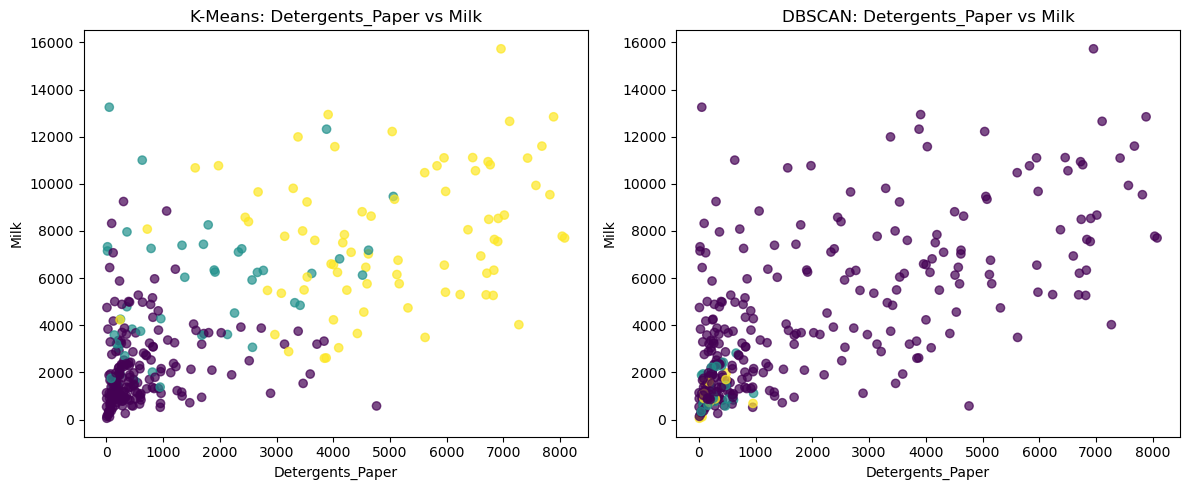

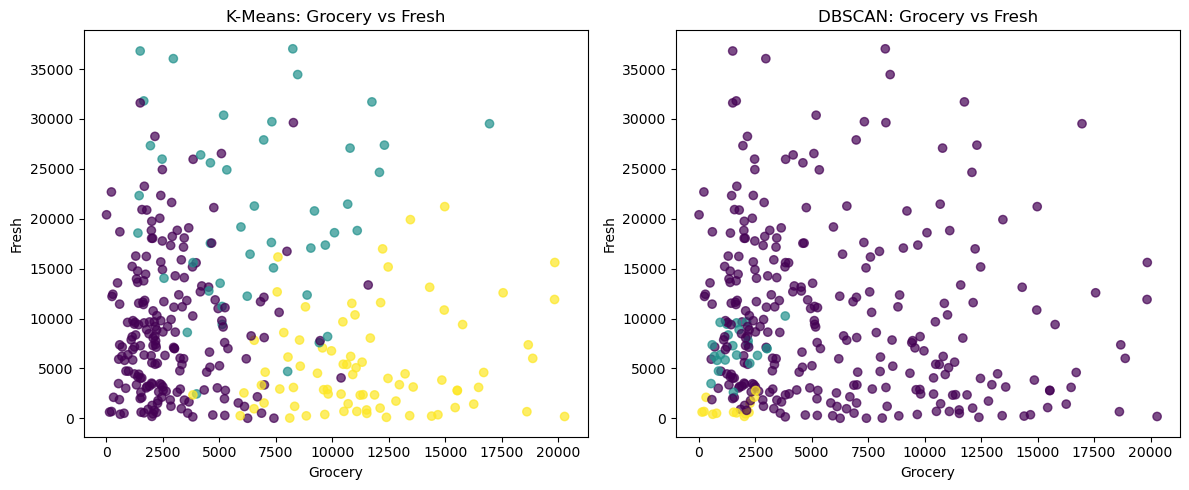

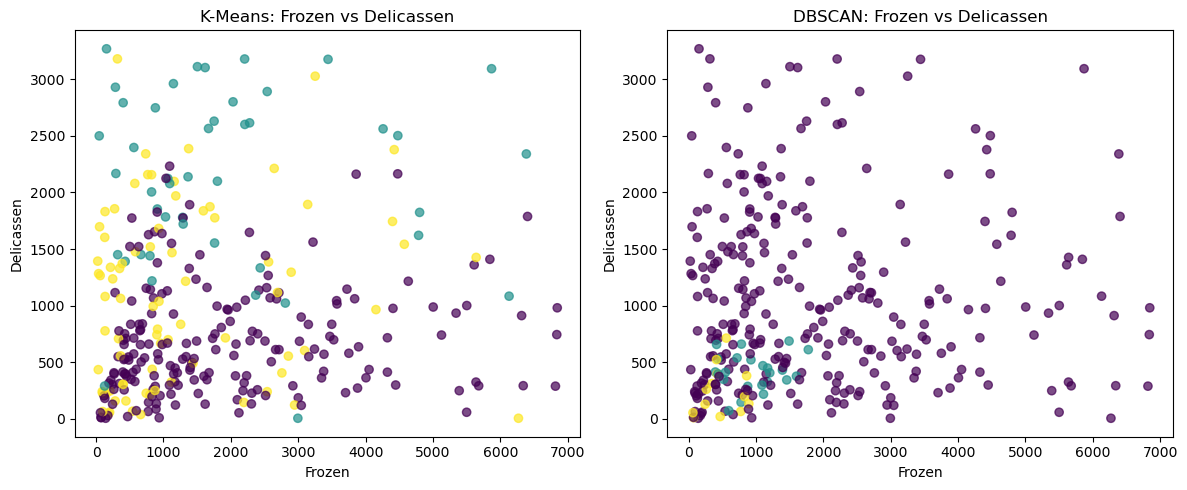

In [69]:
column_pairs = [
    ('Detergents_Paper', 'Milk'),
    ('Grocery', 'Fresh'),
    ('Frozen', 'Delicassen')
]
for x_col, y_col in column_pairs:
    plt.figure(figsize=(12, 5))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(customers_no_outliers['Detergents_Paper'], customers_no_outliers['Milk'], c=customers_no_outliers['labels'], cmap='viridis', alpha=0.7)
plt.title('K-Means: Detergents_Paper vs Milk')
plt.xlabel('Detergents_Paper')
plt.ylabel('Milk')

plt.subplot(1, 2, 2)
plt.scatter(customers_no_outliers['Detergents_Paper'], customers_no_outliers['Milk'], c=customers_no_outliers['labels_DBSCAN'], cmap='viridis', alpha=0.7)
plt.title('DBSCAN: Detergents_Paper vs Milk')
plt.xlabel('Detergents_Paper')
plt.ylabel('Milk')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(customers_no_outliers['Grocery'], customers_no_outliers['Fresh'], c=customers_no_outliers['labels'], cmap='viridis', alpha=0.7)
plt.title('K-Means: Grocery vs Fresh')
plt.xlabel('Grocery')
plt.ylabel('Fresh')

plt.subplot(1, 2, 2)
plt.scatter(customers_no_outliers['Grocery'], customers_no_outliers['Fresh'], c=customers_no_outliers['labels_DBSCAN'], cmap='viridis', alpha=0.7)
plt.title('DBSCAN: Grocery vs Fresh')
plt.xlabel('Grocery')
plt.ylabel('Fresh')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(customers_no_outliers['Frozen'], customers_no_outliers['Delicassen'], c=customers_no_outliers['labels'], cmap='viridis', alpha=0.7)
plt.title('K-Means: Frozen vs Delicassen')
plt.xlabel('Frozen')
plt.ylabel('Delicassen')

plt.subplot(1, 2, 2)
plt.scatter(customers_no_outliers['Frozen'], customers_no_outliers['Delicassen'], c=customers_no_outliers['labels_DBSCAN'], cmap='viridis', alpha=0.7)
plt.title('DBSCAN: Frozen vs Delicassen')
plt.xlabel('Frozen')
plt.ylabel('Delicassen')

plt.tight_layout()
plt.show()

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

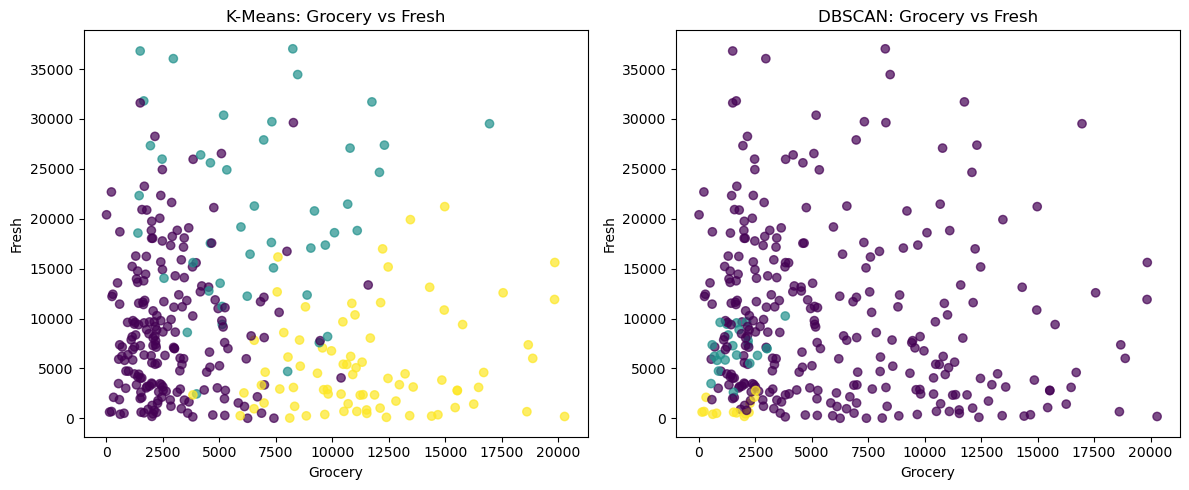

In [71]:
plt.figure(figsize=(12, 5))

# K-Means plot
plt.subplot(1, 2, 1)
plt.scatter(customers_no_outliers['Grocery'], customers_no_outliers['Fresh'], c=customers_no_outliers['labels'], cmap='viridis', alpha=0.7)
plt.title('K-Means: Grocery vs Fresh')
plt.xlabel('Grocery')
plt.ylabel('Fresh')

# DBSCAN plot
plt.subplot(1, 2, 2)
plt.scatter(customers_no_outliers['Grocery'], customers_no_outliers['Fresh'], c=customers_no_outliers['labels_DBSCAN'], cmap='viridis', alpha=0.7)
plt.title('DBSCAN: Grocery vs Fresh')
plt.xlabel('Grocery')
plt.ylabel('Fresh')

plt.tight_layout()
plt.show()

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

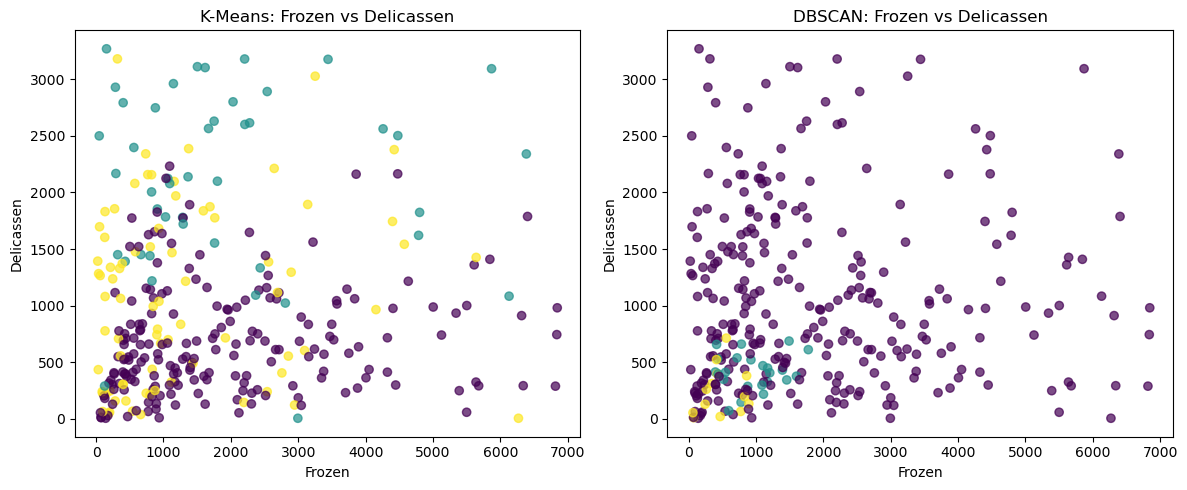

In [73]:
plt.figure(figsize=(12, 5))

# K-Means plot
plt.subplot(1, 2, 1)
plt.scatter(customers_no_outliers['Frozen'], customers_no_outliers['Delicassen'], c=customers_no_outliers['labels'], cmap='viridis', alpha=0.7)
plt.title('K-Means: Frozen vs Delicassen')
plt.xlabel('Frozen')
plt.ylabel('Delicassen')

# DBSCAN plot
plt.subplot(1, 2, 2)
plt.scatter(customers_no_outliers['Frozen'], customers_no_outliers['Delicassen'], c=customers_no_outliers['labels_DBSCAN'], cmap='viridis', alpha=0.7)
plt.title('DBSCAN: Frozen vs Delicassen')
plt.xlabel('Frozen')
plt.ylabel('Delicassen')

plt.tight_layout()
plt.show()

Let's use a groupby to see how the mean differs between the groups. Group `customers` by `labels` and `labels_DBSCAN` respectively and compute the means for all columns.

In [79]:
kmeans_grouped = customers_no_outliers.groupby('labels').mean()

# Group by DBSCAN labels and compute the mean for all columns
dbscan_grouped = customers_no_outliers.groupby('labels_DBSCAN').mean()

kmeans_grouped, dbscan_grouped

(         Channel    Region         Fresh         Milk       Grocery  \
 labels                                                                
 0       1.046154  2.482051   8918.958974  2135.076923   2846.846154   
 1       1.377778  2.666667  20656.311111  5471.777778   6705.155556   
 2       1.769231  2.692308   5405.717949  7769.076923  11697.230769   
 
              Frozen  Detergents_Paper   Delicassen     Label  labels_DBSCAN  
 labels                                                                       
 0       1963.656410        625.748718   687.441026  0.005128      -0.748718  
 1       1954.466667       1604.422222  2118.200000  0.488889      -1.000000  
 2       1300.333333       5014.000000  1071.833333  1.000000      -1.000000  ,
                 Channel    Region         Fresh         Milk      Grocery  \
 labels_DBSCAN                                                               
 -1             1.304965  2.556738  10335.216312  4348.946809  6071.492908   
  0     

Which algorithm appears to perform better?

**Your observations here**

- K-Means provides well-defined, interpretable clusters with meaningful centroids. The mean values of the features across clusters demonstrate distinct spending patterns.

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

C:\Users\torre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


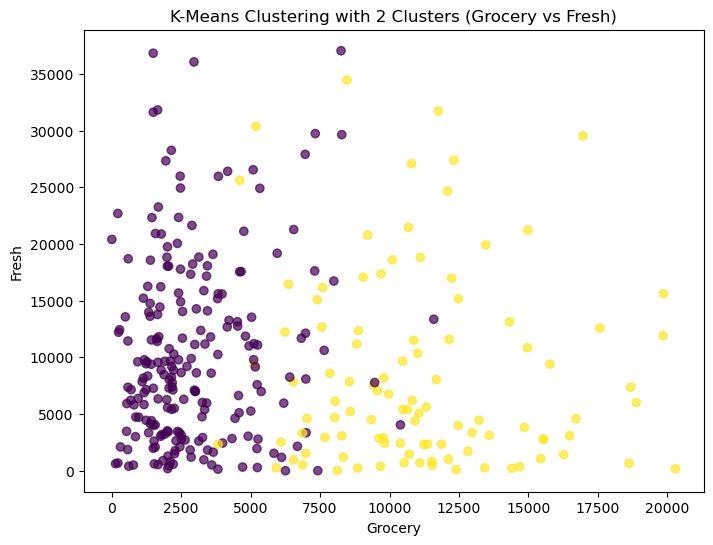

C:\Users\torre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


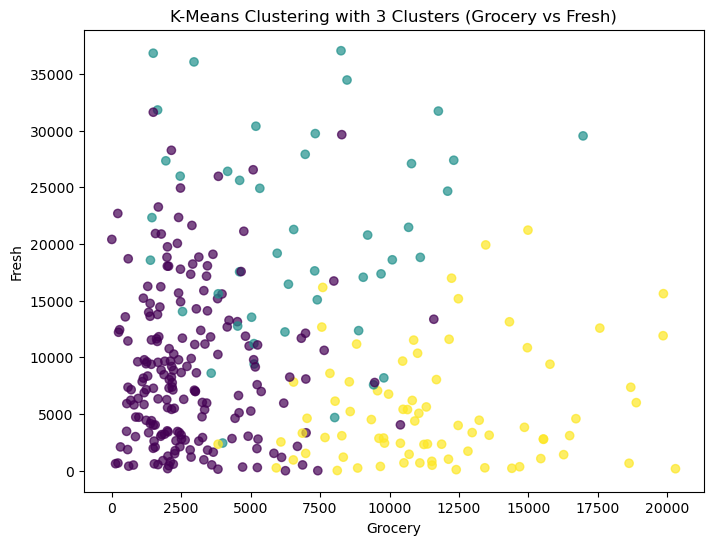

C:\Users\torre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


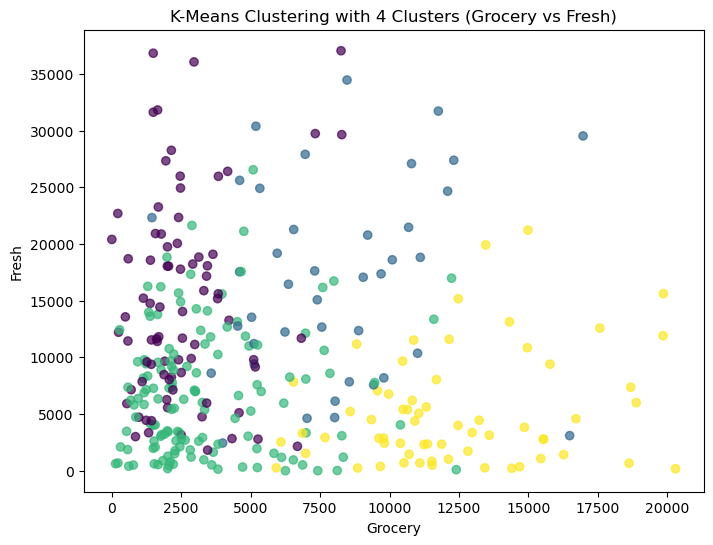

C:\Users\torre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


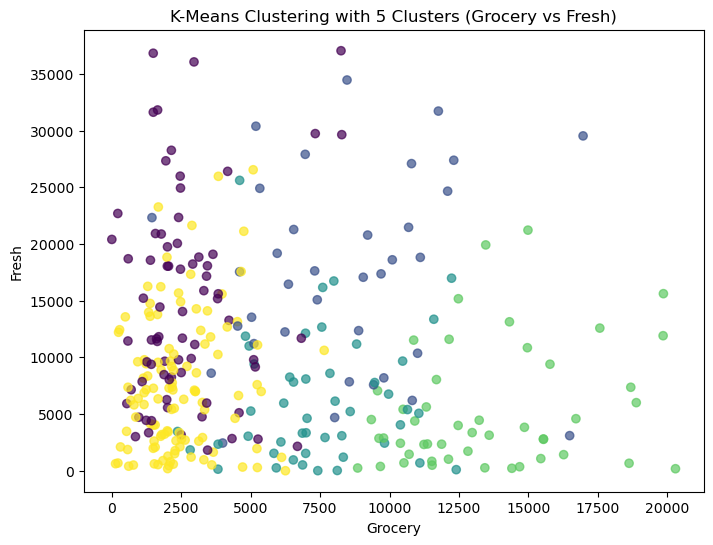

C:\Users\torre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


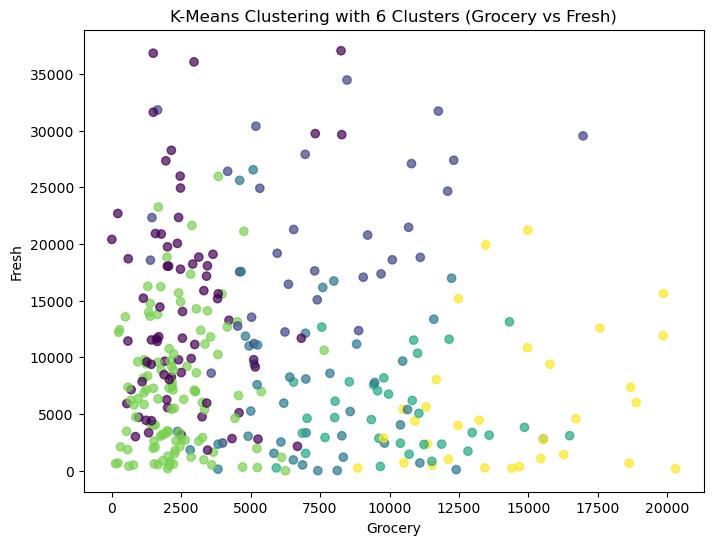

In [82]:
for n_clusters in [2, 3, 4, 5, 6]:  # Testing a range of cluster numbers
    # Initialize and fit K-Means with the current number of clusters
    kmeans_experiment = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_experiment.fit(customers_scale)
    
    # Assign labels to the dataset
    customers_no_outliers[f'labels_kmeans_{n_clusters}'] = kmeans_experiment.labels_
    
    # Visualize a scatter plot for Grocery (X) vs Fresh (Y)
    plt.figure(figsize=(8, 6))
    plt.scatter(customers_no_outliers['Grocery'], customers_no_outliers['Fresh'], 
                c=customers_no_outliers[f'labels_kmeans_{n_clusters}'], cmap='viridis', alpha=0.7)
    plt.title(f'K-Means Clustering with {n_clusters} Clusters (Grocery vs Fresh)')
    plt.xlabel('Grocery')
    plt.ylabel('Fresh')
    plt.show()

**Your comment here**

- 3 to 4 clusters work best for this dataset, balancing interpretability and detail. They capture the broad structure of the data without over-sergmentation. 


# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

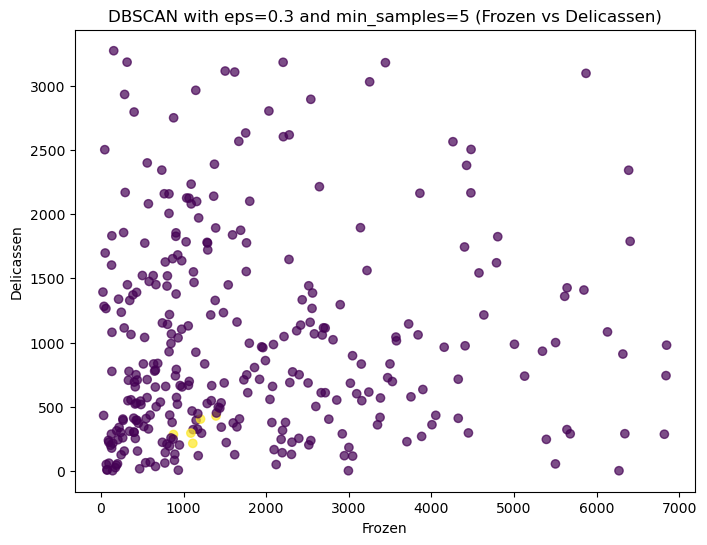

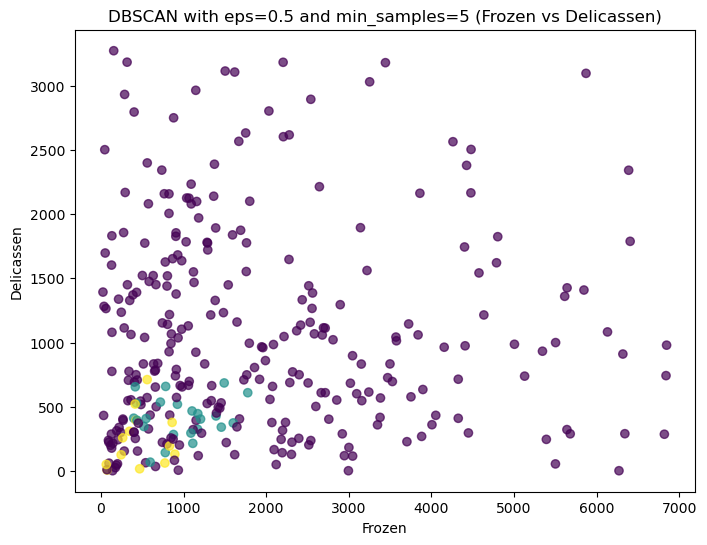

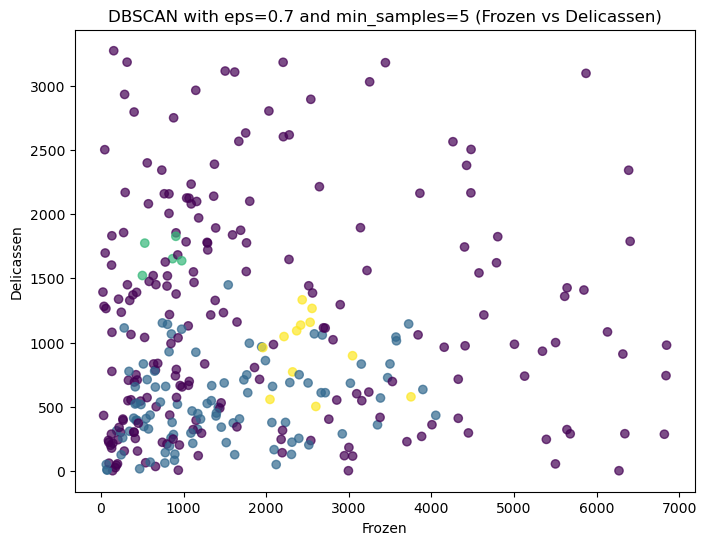

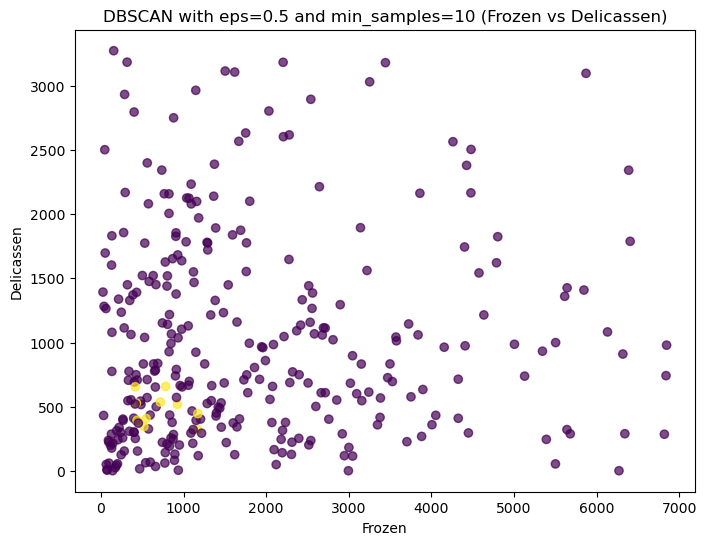

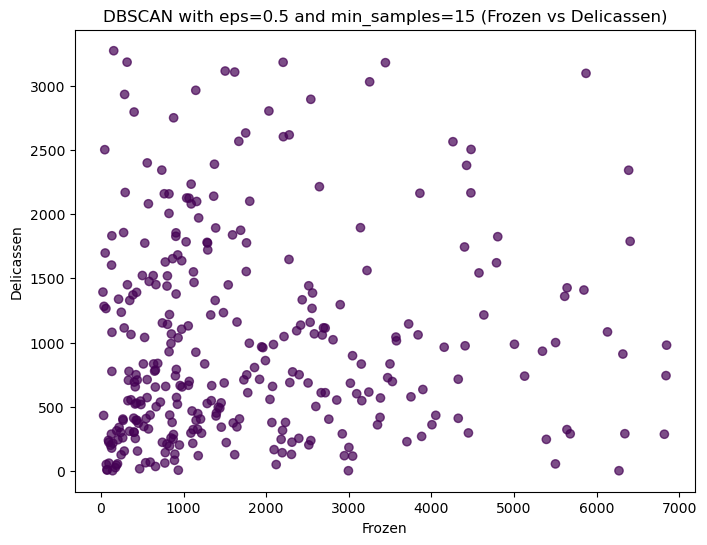

In [85]:
dbscan_params = [
    {'eps': 0.3, 'min_samples': 5},
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 0.7, 'min_samples': 5},
    {'eps': 0.5, 'min_samples': 10},
    {'eps': 0.5, 'min_samples': 15},
]

# Iterate through parameter combinations
for params in dbscan_params:
    # Initialize and fit DBSCAN with the current parameters
    dbscan_experiment = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    dbscan_experiment.fit(customers_scale)
    
    # Assign labels to the dataset
    customers_no_outliers['labels_dbscan_experiment'] = dbscan_experiment.labels_
    
    # Visualize a scatter plot for Frozen (X) vs Delicassen (Y)
    plt.figure(figsize=(8, 6))
    plt.scatter(customers_no_outliers['Frozen'], customers_no_outliers['Delicassen'], 
                c=customers_no_outliers['labels_dbscan_experiment'], cmap='viridis', alpha=0.7)
    plt.title(f"DBSCAN with eps={params['eps']} and min_samples={params['min_samples']} (Frozen vs Delicassen)")
    plt.xlabel('Frozen')
    plt.ylabel('Delicassen')
    plt.show()

**Your comment here**

- 